# Task 3: Linear Regression — House Price Prediction

**Objective:** Implement and understand simple & multiple linear regression.

**Tools:** Scikit-learn, Pandas, Matplotlib

**Dataset:** `Housing.csv` (House Price Prediction Dataset)

**Workflow:**
1. Import and preprocess the dataset
2. Split data into train-test sets
3. Fit a Linear Regression model using `sklearn.linear_model`
4. Evaluate model using MAE, MSE, R²
5. Plot regression line and interpret coefficients


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')


## 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv('Housing.csv')
print("Shape:", df.shape)
df.head()


Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [4]:
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
# Check for missing values
df.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## 3. Preprocess the Dataset

The dataset has several categorical (yes/no) columns and a `furnishingstatus` column.
We'll encode the binary yes/no columns as 1/0, and one-hot encode `furnishingstatus`.


In [6]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']

df_processed = df.copy()
for col in binary_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

df_processed = pd.get_dummies(df_processed, columns=['furnishingstatus'], drop_first=True)

# Convert any bool columns from get_dummies into int
bool_cols = df_processed.select_dtypes(include='bool').columns
df_processed[bool_cols] = df_processed[bool_cols].astype(int)

df_processed.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [7]:
# Correlation with target variable (price)
corr = df_processed.corr(numeric_only=True)['price'].sort_values(ascending=False)
corr


price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

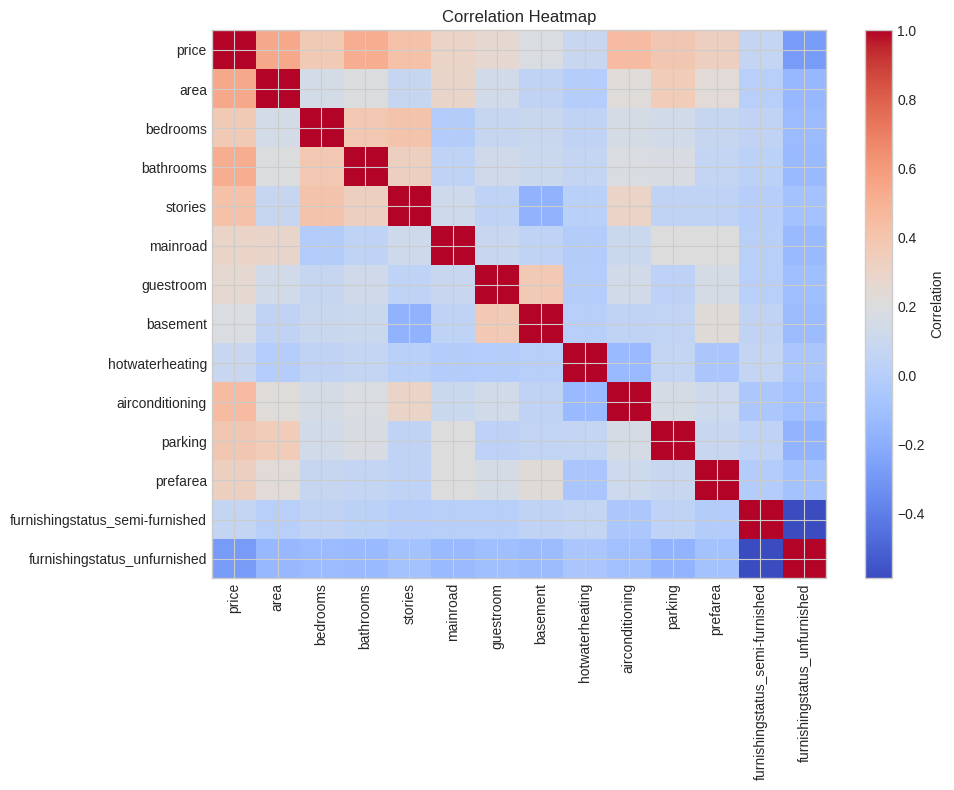

In [8]:
plt.figure(figsize=(10, 8))
plt.imshow(df_processed.corr(numeric_only=True), cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')
cols = df_processed.corr(numeric_only=True).columns
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 4. Simple Linear Regression

We start with **simple linear regression**: predicting `price` using a single feature, `area`
(the feature most intuitively related to price), to build intuition before moving to multiple
regression.


In [9]:
X_simple = df_processed[['area']]
y = df_processed['price']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

y_pred_s = simple_model.predict(X_test_s)

print("Intercept:", simple_model.intercept_)
print("Coefficient (area):", simple_model.coef_[0])


Intercept: 2512254.2639593435
Coefficient (area): 425.72984193878284


In [10]:
mae_s = mean_absolute_error(y_test_s, y_pred_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test_s, y_pred_s)

print(f"MAE:  {mae_s:,.2f}")
print(f"MSE:  {mse_s:,.2f}")
print(f"RMSE: {rmse_s:,.2f}")
print(f"R2:   {r2_s:.4f}")


MAE:  1,474,748.13
MSE:  3,675,286,604,768.19
RMSE: 1,917,103.70
R2:   0.2729


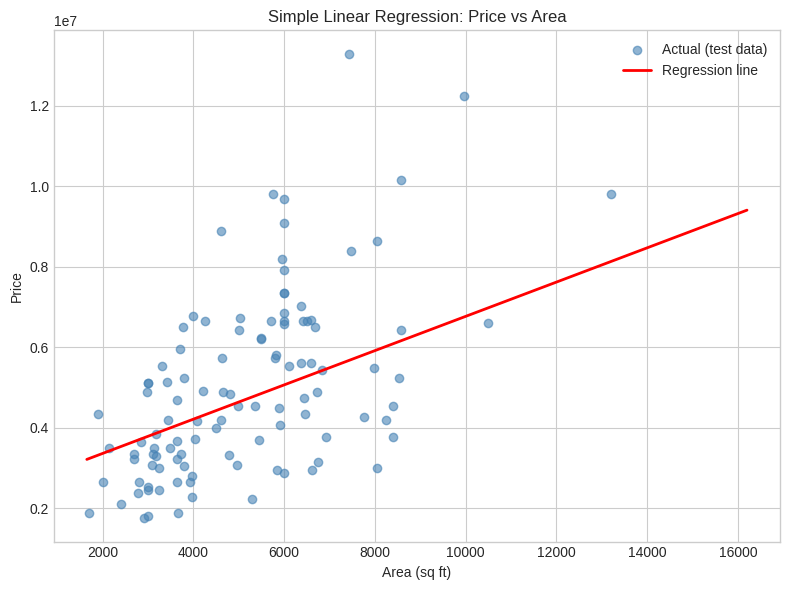

In [11]:
# Plot the regression line against the test data
plt.figure(figsize=(8, 6))
plt.scatter(X_test_s, y_test_s, color='steelblue', alpha=0.6, label='Actual (test data)')

x_line = np.linspace(X_simple['area'].min(), X_simple['area'].max(), 100).reshape(-1, 1)
y_line = simple_model.predict(pd.DataFrame(x_line, columns=['area']))
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression line')

plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.title('Simple Linear Regression: Price vs Area')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** the slope tells us the expected change in `price` for a one-unit
increase in `area`, holding nothing else constant (since this is a single-feature model). The
intercept is the predicted price when area is zero, which is not practically meaningful here but
is required to fit the line.


## 5. Multiple Linear Regression

Now we use **all available features** to predict `price`. This should generally improve fit,
since price depends on more than just area (bedrooms, bathrooms, location perks, etc.).


In [12]:
X = df_processed.drop(columns=['price'])
y = df_processed['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [13]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Intercept:", model.intercept_)
coef_df


Intercept: 260032.3576074103


,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
12,furnishingstatus_unfurnished,-4.136451e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05


In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")


MAE:  970,043.40
MSE:  1,754,318,687,330.66
RMSE: 1,324,506.96
R2:   0.6529


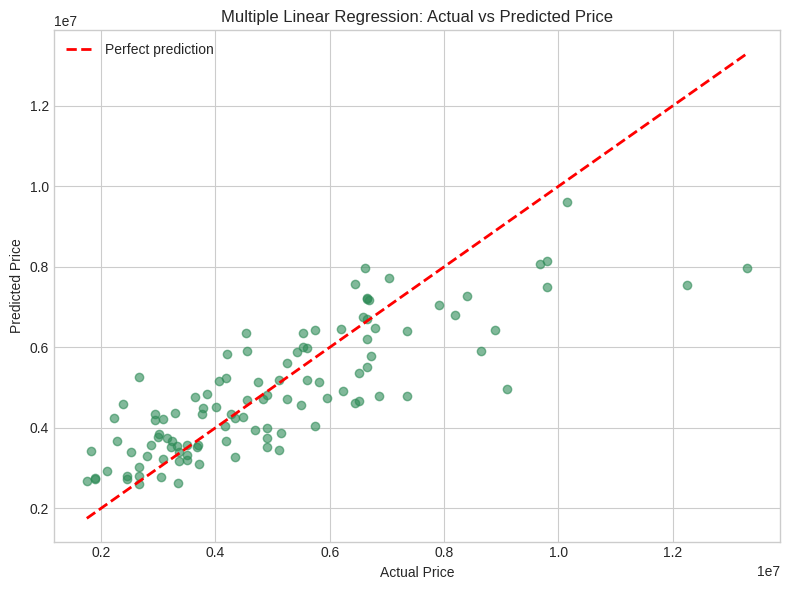

In [15]:
# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='seagreen', alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linewidth=2, linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Multiple Linear Regression: Actual vs Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()


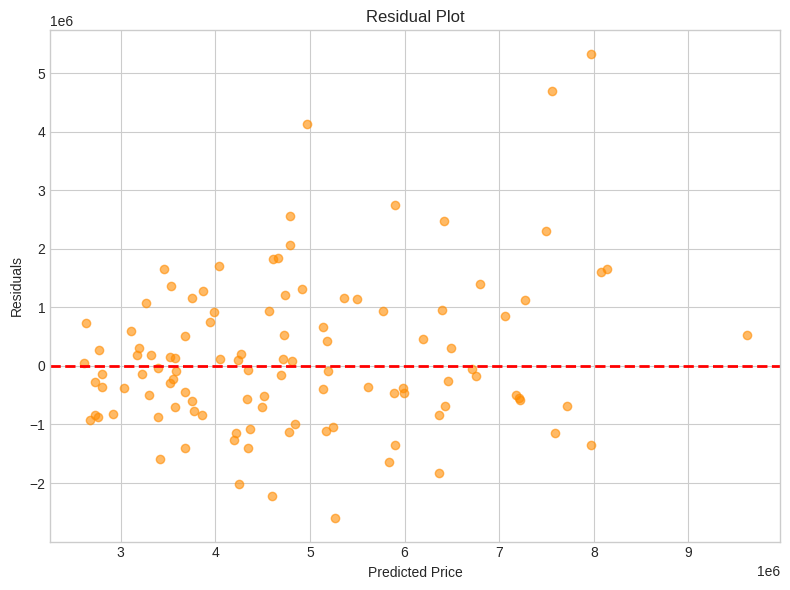

In [16]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='darkorange', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()


**Interpretation of coefficients:** each coefficient represents the expected change in
`price` for a one-unit increase in that feature, **holding all other features constant**. For
example, the coefficient for `bathrooms` tells us how much price is expected to increase for one
additional bathroom, assuming area, bedrooms, and everything else stay the same. Binary (yes/no)
features like `airconditioning` show the average price difference between homes with and without
that amenity, all else equal.

Comparing the simple vs multiple regression R² scores shows how much additional explanatory power
comes from including more features.


In [17]:
print(f"Simple Regression (area only)   R2: {r2_s:.4f}")
print(f"Multiple Regression (all features) R2: {r2:.4f}")


Simple Regression (area only)   R2: 0.2729
Multiple Regression (all features) R2: 0.6529
